In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("SampleSuperstore.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [3]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [5]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [6]:
df.columns=df.columns.str.strip().str.lower().str.replace(' ','_')
df.columns

Index(['ship_mode', 'segment', 'country', 'city', 'state', 'postal_code',
       'region', 'category', 'sub-category', 'sales', 'quantity', 'discount',
       'profit'],
      dtype='object')

In [7]:
print("Duplicates:",df.duplicated().sum())
print(df.isnull().sum())

Duplicates: 17
ship_mode       0
segment         0
country         0
city            0
state           0
postal_code     0
region          0
category        0
sub-category    0
sales           0
quantity        0
discount        0
profit          0
dtype: int64


In [8]:
total_sales=df['sales'].sum()
total_profit=df['profit'].sum()
total_orders=len(df)
avg_discount=df['discount'].mean()

print("Total Sales:",total_sales)
print("Total Profit:",total_profit)
print("Total Rows:",total_orders)
print("Average Discount:",avg_discount)

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Rows: 9994
Average Discount: 0.1562027216329798


In [9]:
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)
category_sales

category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64

In [10]:
category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=False)
category_profit

category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: profit, dtype: float64

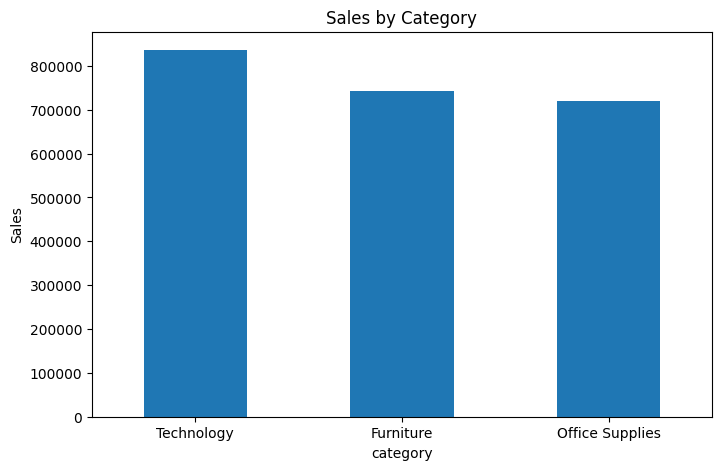

In [11]:
category_sales.plot(kind='bar',figsize=(8,5))
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

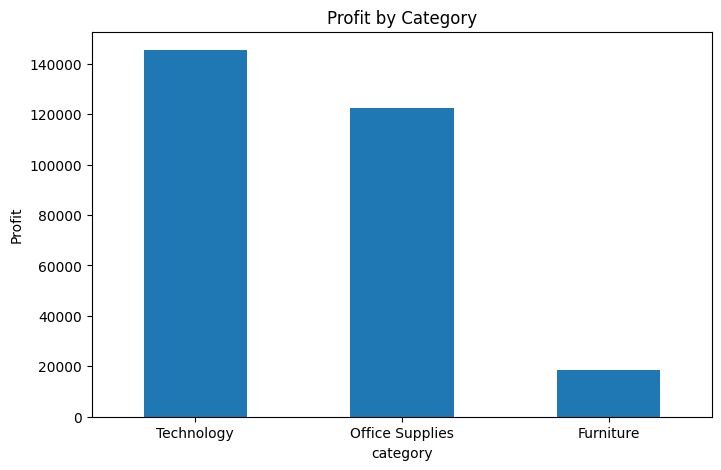

In [12]:
category_profit.plot(kind='bar',figsize=(8,5))
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

In [13]:
region_summary=df.groupby('region')[['sales','profit']].sum().sort_values(by='sales',ascending=False)
region_summary

,sales,profit
region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


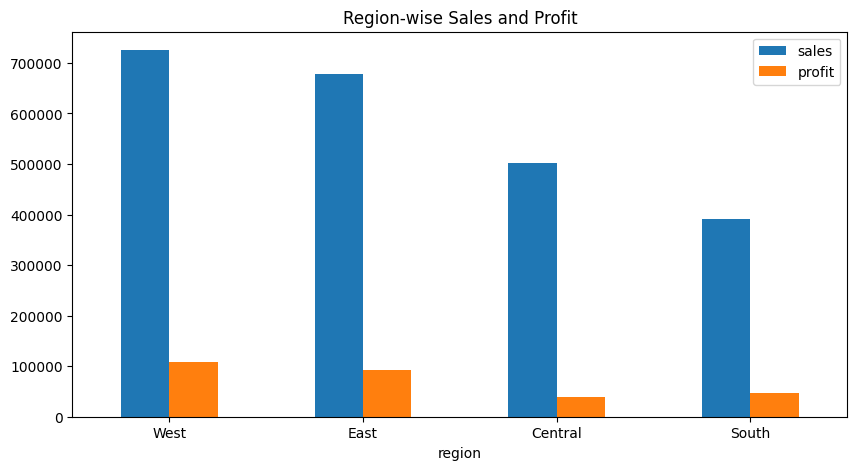

In [14]:
region_summary.plot(kind='bar',figsize=(10,5))
plt.title("Region-wise Sales and Profit")
plt.xticks(rotation=0)
plt.show()

In [15]:
subcat_profit=df.groupby('sub-category')['profit'].sum().sort_values()
subcat_profit

sub-category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: profit, dtype: float64

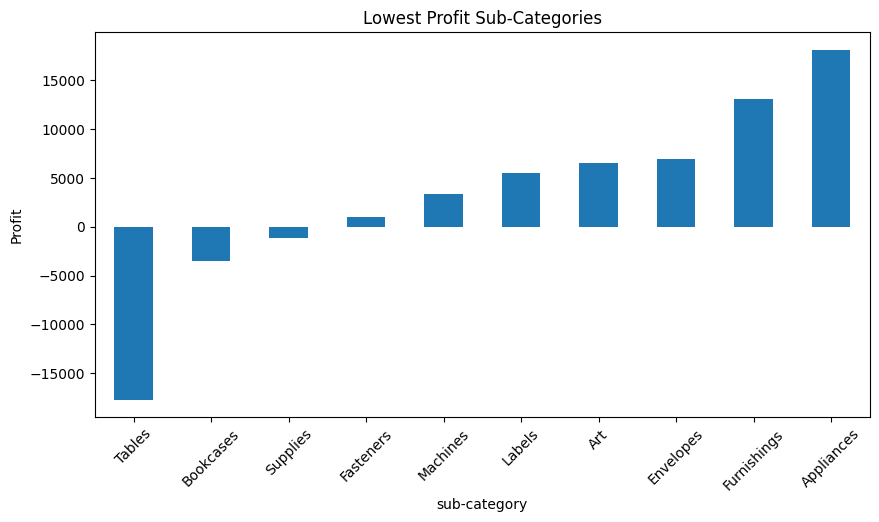

In [16]:
subcat_profit.head(10).plot(kind='bar',figsize=(10,5))
plt.title("Lowest Profit Sub-Categories")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

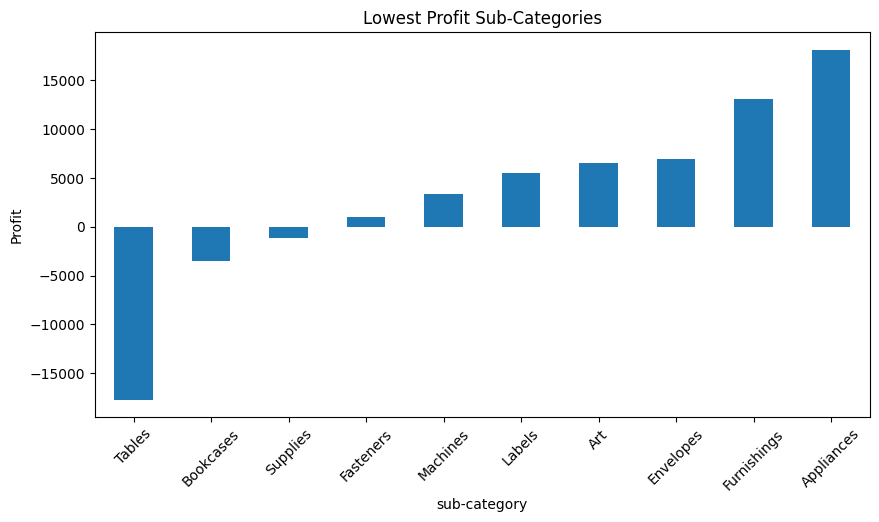

In [17]:
subcat_profit.head(10).plot(kind='bar',figsize=(10,5))
plt.title("Lowest Profit Sub-Categories")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

In [18]:
segment_summary=df.groupby('segment')[['sales','profit']].sum().sort_values(by='sales',ascending=False)
segment_summary

,sales,profit
segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


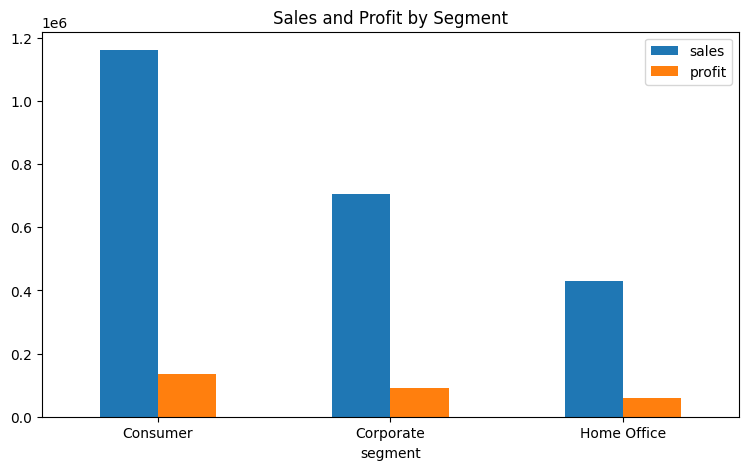

In [19]:
segment_summary.plot(kind='bar',figsize=(9,5))
plt.title("Sales and Profit by Segment")
plt.xticks(rotation=0)
plt.show()

In [20]:
state_profit=df.groupby('state')['profit'].sum().sort_values()
state_profit.tail(10)

state
Delaware       9977.3748
Minnesota     10823.1874
Kentucky      11199.6966
Georgia       16250.0433
Indiana       18382.9363
Virginia      18597.9504
Michigan      24463.1876
Washington    33402.6517
New York      74038.5486
California    76381.3871
Name: profit, dtype: float64

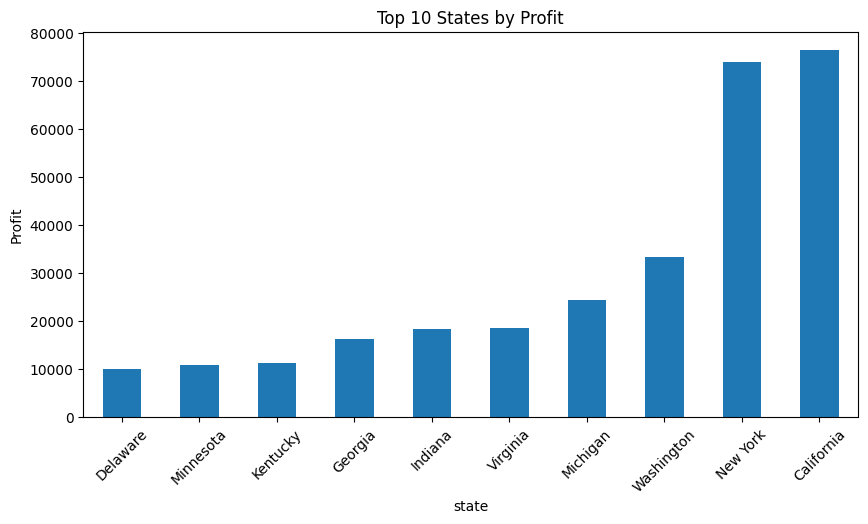

In [21]:
plt.figure(figsize=(10,5))
state_profit.tail(10).plot(kind='bar')
plt.title("Top 10 States by Profit")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

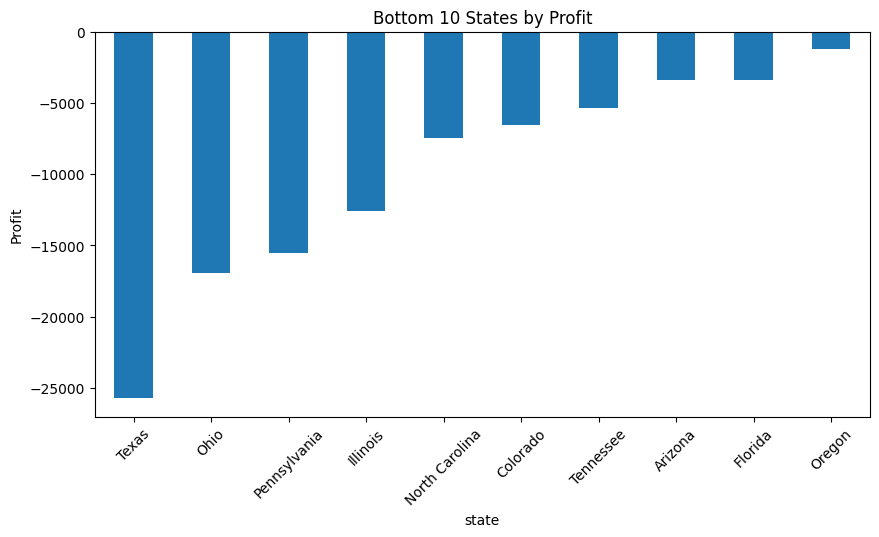

In [22]:
plt.figure(figsize=(10,5))
state_profit.head(10).plot(kind='bar')
plt.title("Bottom 10 States by Profit")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

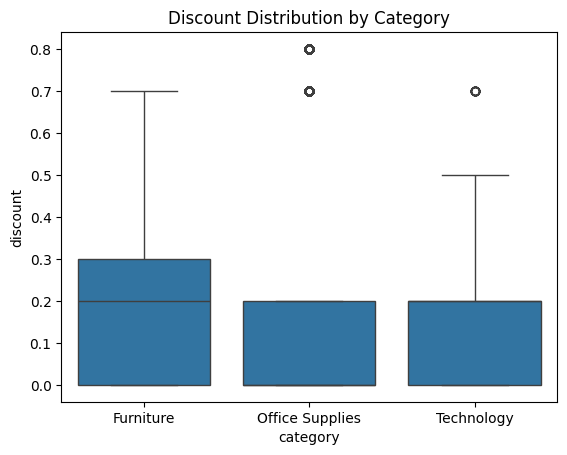

In [23]:
sns.boxplot(data=df,x='category',y='discount')
plt.title("Discount Distribution by Category")
plt.xticks(rotation=0)
plt.show()

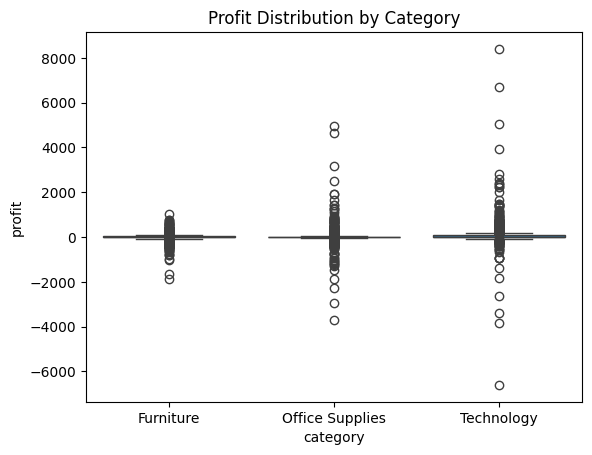

In [24]:
sns.boxplot(data=df,x='category',y='profit')
plt.title("Profit Distribution by Category")
plt.xticks(rotation=0)
plt.show()